# HDT 6: Boosting e Inferencia Causal

**Ciencia de Datos, Sección A** · Asignada: martes 6 de octubre · **Entrega: martes 13 de octubre, 23:59**

**Nombre:** Juan Pablo Madriz

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la bitácora del final (no penaliza).

## Setup

Dependencias: `pip install numpy pandas matplotlib scikit-learn`. Todo es determinista (semillas fijas y splits fijos): las verificaciones son exactas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Los datos

Dos historias, dos datasets:

**Repartos** (partes A y B): una repartidora quiere predecir cuántos `minutos` toma cada entrega, con `distancia` (km) y `paquetes`. Es el mismo tipo de problema que las tiendas de la sesión 18.

**Socios y el curso de finanzas** (parte C): el banco ofrece un curso de finanzas personales y observa que quienes lo tomaron pagan más puntual. ¿El curso causa la puntualidad? El mismo tipo de trampa que la app de la sesión 19.

Las celdas generan los datos completas; no hay nada que llenar aquí.

In [2]:
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(6)
m = 350
distancia = rng.uniform(1, 20, m).round(1)
paquetes = rng.integers(1, 9, m)
minutos = (12 + 2.6 * distancia + 3.5 * paquetes + 0.15 * distancia * paquetes
           + rng.normal(0, 6, m)).round(1)
repartos = pd.DataFrame({"distancia": distancia, "paquetes": paquetes, "minutos": minutos})

R_train, R_test = train_test_split(repartos, test_size=0.3, random_state=1)
Xr, yr = R_train[["distancia", "paquetes"]], R_train["minutos"]
Xr_test, yr_test = R_test[["distancia", "paquetes"]], R_test["minutos"]
print("repartos:", len(R_train), "entrenamiento |", len(R_test), "prueba",
      "| promedio del entrenamiento:", round(yr.mean(), 1), "min")

rng_c = np.random.default_rng(60)
n = 2000
antiguedad = rng_c.integers(0, 20, n)
curso = (rng_c.random(n) < 1 / (1 + np.exp(-(antiguedad - 10) / 3))).astype(int)
puntual = (rng_c.random(n) < 1 / (1 + np.exp(-(-0.3 + (antiguedad - 10) / 4)))).astype(int)
socios = pd.DataFrame({"antiguedad": antiguedad, "curso": curso, "puntual": puntual})
print("socios:", len(socios), "| tomaron el curso:", socios["curso"].mean().round(2),
      "| pagan puntual:", socios["puntual"].mean().round(2))

repartos: 245 entrenamiento | 105 prueba | promedio del entrenamiento: 62.6 min
socios: 2000 | tomaron el curso: 0.48 | pagan puntual: 0.42


## Parte A · Boosting: árboles en fila (0.5 pt)

La sesión 18 con otra flota: cada árbol aprende lo que al anterior le faltó, y se agrega una fracción de su corrección.

### Ejercicio 1 (0.20): el paso 0 y el primer árbol

(a) El paso 0: predecir el promedio del entrenamiento para todos. ¿Cuál es el error absoluto promedio en prueba de ese modelo? (b) Entrenar un `DecisionTreeRegressor(max_depth=2, random_state=0)` sobre **lo que falta** (`yr - promedio`). (c) Armar la tabla de los primeros 3 repartos de prueba: minutos reales, predicción del paso 0, lo que falta, lo que agrega el árbol (la mitad de su corrección: paso 0.5) y la nueva predicción.

In [3]:
from sklearn.tree import DecisionTreeRegressor

promedio = yr.mean()
error_promedio = (yr_test - promedio).abs().mean()   # error absoluto promedio usando solo el promedio

arbol1 = DecisionTreeRegressor(max_depth=2, random_state=0).fit(Xr, yr - promedio)

tabla = R_test.head(3).copy()
tabla["pred0"] = round(promedio, 1)
tabla["falta"] = tabla["minutos"] - tabla["pred0"]                          # lo que el paso 0 dejó pendiente
tabla["agrega"] = 0.5 * arbol1.predict(tabla[["distancia", "paquetes"]])    # la mitad de la corrección
tabla["nueva"] = tabla["pred0"] + tabla["agrega"]

print(f"paso 0: predecir {promedio:.1f} min para todos")
print(f"error absoluto promedio en prueba = {error_promedio:.1f} min\n")
print(tabla.round(1).to_string())

# Verificación:
assert round(error_promedio, 1) == 19.7
assert round(tabla["agrega"].iloc[1], 1) == 15.2
assert round(tabla["nueva"].iloc[1], 1) == 77.8
print("\nEjercicio 1 verificado.")

paso 0: predecir 62.6 min para todos
error absoluto promedio en prueba = 19.7 min

     distancia  paquetes  minutos  pred0  falta  agrega  nueva
192       10.6         4     49.8   62.6  -12.8    -2.6   60.0
256       14.8         5     85.3   62.6   22.7    15.2   77.8
169       12.8         4     67.1   62.6    4.5     2.6   65.2

Ejercicio 1 verificado.


### Ejercicio 2 (0.15): la fila completa

Completar `boosting_a_mano`: en cada vuelta, entrenar un árbol de profundidad 2 sobre lo que falta, sumar `paso` veces su corrección a las predicciones (de entrenamiento y de prueba) y guardar el error de prueba. Correrla con 8 árboles y paso 0.5.

In [4]:
def boosting_a_mano(X, y, X_nuevo, y_nuevo, n_arboles, paso):
    pred = np.full(len(y), y.mean())
    pred_nuevo = np.full(len(y_nuevo), y.mean())
    errores = []
    for _ in range(n_arboles):
        arbol = DecisionTreeRegressor(max_depth=2, random_state=0).fit(X, y - pred)   # 1) sobre lo que falta
        pred = pred + paso * arbol.predict(X)                                         # 2) una fracción de la corrección
        pred_nuevo = pred_nuevo + paso * arbol.predict(X_nuevo)
        errores.append(np.abs(y_nuevo - pred_nuevo).mean())                           # 3) error de prueba de la vuelta
    return errores

errores = boosting_a_mano(Xr, yr, Xr_test, yr_test, n_arboles=8, paso=0.5)
for i, e in enumerate(errores, start=1):
    print(f"  {i} árbol(es): error en prueba = {e:5.1f} min")

# Verificación:
assert round(errores[0], 1) == 12.7
assert round(errores[-1], 1) == 5.7
print("\nEjercicio 2 verificado.")

  1 árbol(es): error en prueba =  12.7 min
  2 árbol(es): error en prueba =   9.7 min
  3 árbol(es): error en prueba =   7.4 min
  4 árbol(es): error en prueba =   6.6 min
  5 árbol(es): error en prueba =   6.2 min
  6 árbol(es): error en prueba =   6.0 min
  7 árbol(es): error en prueba =   5.8 min
  8 árbol(es): error en prueba =   5.7 min

Ejercicio 2 verificado.


### Ejercicio 3 (0.15): qué tanto corregir en cada paso

Correr `boosting_a_mano` con 8 árboles y pasos 0.1, 0.5 y 1.0. Graficar las tres curvas de error (una línea por paso) y responder en un comentario: ¿cuál termina mejor, y qué le pasa a cada extremo?

paso 0.1:  18.2  16.8  15.6  14.5  13.5  12.6  11.9  11.2
paso 0.5:  12.7   9.7   7.4   6.6   6.2   6.0   5.8   5.7
paso 1.0:   9.6   8.2   7.7   7.2   6.9   6.9   6.8   6.5


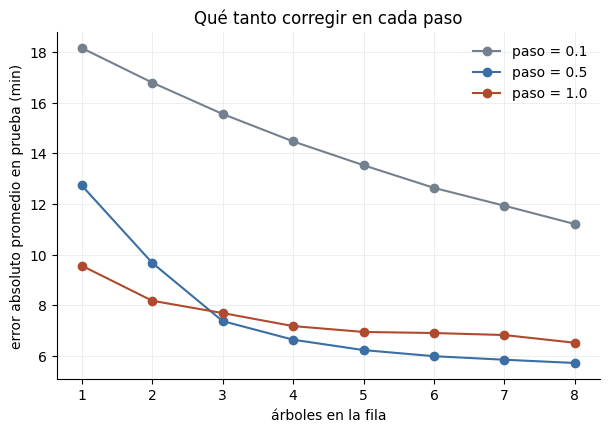


error final tras 8 árboles:
  paso 0.1: 11.2 min
  paso 0.5: 5.7 min
  paso 1.0: 6.5 min
Ejercicio 3 verificado.


In [ ]:
finales = {}

fig, ax = plt.subplots(figsize=(7, 4.5))
for paso, color in zip([0.1, 0.5, 1.0], [GRIS, AZUL, ROJO]):
    curva = boosting_a_mano(Xr, yr, Xr_test, yr_test, n_arboles=8, paso=paso)
    ax.plot(range(1, len(curva) + 1), curva, marker="o", color=color, label=f"paso = {paso}")
    finales[paso] = curva[-1]
    print(f"paso {paso}: " + " ".join(f"{e:5.1f}" for e in curva))

ax.set_xlabel("árboles en la fila")
ax.set_ylabel("error absoluto promedio en prueba (min)")
ax.set_title("Qué tanto corregir en cada paso")
ax.legend(frameon=False)
eje_limpio(ax)
plt.show()

print("\nerror final tras 8 árboles:")
for paso, final in finales.items():
    print(f"  paso {paso}: {final:.1f} min")

# Verificación:
assert round(finales[0.1], 1) == 11.2
assert round(finales[0.5], 1) == 5.7
assert round(finales[1.0], 1) == 6.5
print("Ejercicio 3 verificado.")

## Parte B · ¿Bosque o boosting? (0.3 pt)

### Ejercicio 4 (0.15): los tres sobre la misma prueba

Comparar el error absoluto promedio en prueba de: el promedio a secas, un `RandomForestRegressor` (300 árboles, `random_state=0`) y un `HistGradientBoostingRegressor` (`random_state=0`).

In [ ]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

bosque = RandomForestRegressor(n_estimators=300, random_state=0).fit(Xr, yr)
error_bosque = np.abs(yr_test - bosque.predict(Xr_test)).mean()

boosting = HistGradientBoostingRegressor(random_state=0).fit(Xr, yr)
error_boosting = np.abs(yr_test - boosting.predict(Xr_test)).mean()

print(f"solo el promedio       : {error_promedio:5.1f} min")
print(f"bosque (300 árboles)   : {error_bosque:5.1f} min")
print(f"boosting (por defecto) : {error_boosting:5.1f} min")

# Verificación:
assert round(error_bosque, 1) == 5.4
assert round(error_boosting, 1) == 5.3
print("\nEjercicio 4 verificado.")

solo el promedio       :  19.7 min
bosque (300 árboles)   :   5.4 min
boosting (por defecto) :   5.3 min

Ejercicio 4 verificado.


### Ejercicio 5 (0.15): parar a tiempo

Entrenar `HistGradientBoostingRegressor(max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=0)`. ¿En cuántos árboles se detuvo (`n_iter_`) de los 500 permitidos? ¿Su error en prueba empeoró respecto al ejercicio 4?

In [ ]:
temprano = HistGradientBoostingRegressor(max_iter=500, early_stopping=True,
                                         validation_fraction=0.15, random_state=0).fit(Xr, yr)
arboles_usados = temprano.n_iter_
error_temprano = np.abs(yr_test - temprano.predict(Xr_test)).mean()

print(f"se detuvo en {arboles_usados} árboles de los 500 permitidos")
print(f"error en prueba con freno automático : {error_temprano:.1f} min")
print(f"error en prueba del ejercicio 4      : {error_boosting:.1f} min")
print(f"diferencia                           : {error_temprano - error_boosting:+.1f} min")

# Verificación:
assert arboles_usados == 46
assert round(error_temprano, 1) == 5.6
print("\nEjercicio 5 verificado.")

se detuvo en 46 árboles de los 500 permitidos
error en prueba con freno automático : 5.6 min
error en prueba del ejercicio 4      : 5.3 min
diferencia                           : +0.4 min

Ejercicio 5 verificado.


## Parte C · Inferencia causal (1.0 pt)

La sesión 19 con el curso de finanzas: predecir no es intervenir, y la diferencia cruda casi nunca es el efecto.

### Ejercicio 6 (0.20): la diferencia cruda

La tasa de pago puntual de quienes tomaron el curso contra quienes no. Calcular ambas (en %) y la diferencia. Es el número que el gerente quiere presentar; guardarlo para compararlo después.

In [8]:
tasas = socios.groupby("curso")["puntual"].mean() * 100
dif_cruda = tasas.loc[1] - tasas.loc[0]

print(f"sin curso : {tasas.loc[0]:.1f}% paga puntual")
print(f"con curso : {tasas.loc[1]:.1f}% paga puntual")
print(f"diferencia cruda = {dif_cruda:.1f} puntos porcentuales")

# Verificación:
assert round(dif_cruda, 1) == 35.4
print("\nEjercicio 6 verificado.")

sin curso : 25.3% paga puntual
con curso : 60.7% paga puntual
diferencia cruda = 35.4 puntos porcentuales

Ejercicio 6 verificado.


### Ejercicio 7 (0.20): comparar dentro de grupos parecidos

Cortar `antiguedad` en tres niveles con `pd.cut(socios["antiguedad"], [-1, 6, 13, 19], labels=["nuevo", "medio", "veterano"])`. Para cada nivel: la tasa puntual con y sin curso, y su diferencia. Reportar el promedio de las tres diferencias y compararlo con la cruda.

In [ ]:
socios["nivel"] = pd.cut(socios["antiguedad"], [-1, 6, 13, 19],
                         labels=["nuevo", "medio", "veterano"])

por_nivel = socios.groupby(["nivel", "curso"], observed=True)["puntual"].mean().unstack() * 100
por_nivel.columns = ["sin curso", "con curso"]
dif_por_nivel = por_nivel["con curso"] - por_nivel["sin curso"]
por_nivel["diferencia"] = dif_por_nivel
dif_promedio = dif_por_nivel.mean()

print(por_nivel.round(1).to_string())
print(f"\npromedio de las tres diferencias = {dif_promedio:.1f} puntos")
print(f"diferencia cruda del ejercicio 6 = {dif_cruda:.1f} puntos")

# Verificación:
assert round(dif_por_nivel["medio"], 1) == 0.1
assert round(dif_promedio, 1) == 4.4
print("\nEjercicio 7 verificado.")

          sin curso  con curso  diferencia
nivel                                     
nuevo          12.2       20.7         8.6
medio          42.5       42.5         0.1
veterano       73.8       78.2         4.4

promedio de las tres diferencias = 4.4 puntos
diferencia cruda del ejercicio 6 = 35.4 puntos

Ejercicio 7 verificado.


### Ejercicio 8 (0.20): la paradoja de Simpson

Un programa de tutorías, dos cursos. Calcular la tasa de aprobados por fila, y luego la tasa total de cada grupo (con y sin tutor) juntando los dos cursos. ¿Qué se invierte? ¿A cuál número hay que creerle y por qué?

In [ ]:
tutorias = pd.DataFrame({
    "curso": ["Cálculo", "Cálculo", "Álgebra", "Álgebra"],
    "tutor": ["no", "sí", "no", "sí"],
    "estudiantes": [300, 100, 100, 300],
    "aprobaron": [255, 92, 60, 207],
})

# (a) tasa de aprobados por fila
tutorias["tasa"] = (tutorias["aprobaron"] / tutorias["estudiantes"] * 100).round(2)
print("por curso:")
print(tutorias.to_string(index=False))

# (b) tabla total por tutor, juntando los dos cursos
total = tutorias.groupby("tutor")[["estudiantes", "aprobaron"]].sum()
total["tasa"] = (total["aprobaron"] / total["estudiantes"] * 100).round(2)
print("\njuntando los dos cursos:")
print(total.to_string())

# Verificación:
assert tutorias["tasa"].tolist() == [85.0, 92.0, 60.0, 69.0]
assert round(total.loc["sí", "tasa"], 2) == 74.75 and round(total.loc["no", "tasa"], 2) == 78.75
print("\nEjercicio 8 verificado.")

por curso:
  curso tutor  estudiantes  aprobaron  tasa
Cálculo    no          300        255  85.0
Cálculo    sí          100         92  92.0
Álgebra    no          100         60  60.0
Álgebra    sí          300        207  69.0

juntando los dos cursos:
       estudiantes  aprobaron   tasa
tutor                               
no             400        315  78.75
sí             400        299  74.75

Ejercicio 8 verificado.


### Ejercicio 9 (0.20): importante para predecir no es causa

Dos logísticas para predecir `puntual`: el modelo A solo con `curso`; el modelo B con `curso` y `antiguedad`. Comparar el coeficiente de `curso` en cada una. ¿Qué le pasa cuando la causa real entra al modelo?

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_a = LogisticRegression().fit(socios[["curso"]], socios["puntual"])
modelo_b = LogisticRegression().fit(socios[["curso", "antiguedad"]], socios["puntual"])

coef_curso_a = modelo_a.coef_[0][0]
coef_curso_b = modelo_b.coef_[0][0]
coef_antiguedad_b = modelo_b.coef_[0][1]

print(f"modelo A (solo curso)            : coef curso = {coef_curso_a:+.2f}")
print(f"modelo B (curso + antigüedad)    : coef curso = {coef_curso_b:+.2f}")
print(f"                                   coef antigüedad = {coef_antiguedad_b:+.2f}")

# Verificación:
assert round(coef_curso_a, 2) == 1.5
assert round(coef_curso_b, 2) == -0.08
print("\nEjercicio 9 verificado.")

modelo A (solo curso)            : coef curso = +1.50
modelo B (curso + antigüedad)    : coef curso = -0.08
                                   coef antigüedad = +0.24

Ejercicio 9 verificado.


### Ejercicio 10 (0.20): el colisionador, con dos monedas

Tirar dos monedas independientes 4,000 veces (`np.random.default_rng(61).integers(0, 2, 4000)` para cada una, en ese orden). (a) Su correlación: debe ser ~0. (b) Filtrar solo las tiradas donde salió al menos una cara y recalcular la correlación entre las que pasaron el filtro. ¿Qué apareció?

In [ ]:
rng_m = np.random.default_rng(61)
moneda1 = rng_m.integers(0, 2, 4000)
moneda2 = rng_m.integers(0, 2, 4000)

corr_sin_filtro = np.corrcoef(moneda1, moneda2)[0, 1]
pasan = (moneda1 == 1) | (moneda2 == 1)          # al menos una cara
corr_filtrada = np.corrcoef(moneda1[pasan], moneda2[pasan])[0, 1]

print(f"correlación sin filtro            : {corr_sin_filtro:+.3f}   (4000 tiradas)")
print(f"correlación entre las que pasan   : {corr_filtrada:+.3f}   ({pasan.sum()} tiradas)")

# Verificación:
assert abs(corr_sin_filtro) < 0.05
assert round(corr_filtrada, 2) == -0.49
print("\nEjercicio 10 verificado.")

correlación sin filtro            : +0.023   (4000 tiradas)
correlación entre las que pasan   : -0.490   (2968 tiradas)

Ejercicio 10 verificado.


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** El gerente propone: "los del curso pagan 35 puntos mejor; hagámoslo obligatorio y la puntualidad sube 35 puntos". Con los ejercicios 6, 7 y 9, explicar qué está mal y qué subida es realista esperar.

**(b)** ¿Qué tendría que hacer el banco para medir el efecto REAL del curso? Describir el diseño en 2-3 líneas y explicar por qué resuelve el problema que los datos observados no pueden resolver.

_(Responder editando esta celda)_

**Respuesta (a):** Los 35.4 puntos del ejercicio 6 (60.7% contra 25.3%) no son el efecto del curso: son la diferencia entre dos grupos de socios distintos. La antigüedad empuja las dos cosas a la vez, así que quienes tomaron el curso ya eran los veteranos, que pagan puntual por su cuenta. Al comparar socios de antigüedad parecida (ejercicio 7) la ventaja cae a 4.4 puntos en promedio y en el nivel medio se vuelve 0.1; el ejercicio 9 lo confirma desde el modelo: el coeficiente del curso pasa de +1.50 a -0.08 en cuanto entra `antiguedad` (+0.24 por año). Hacerlo obligatorio tampoco convierte a nadie en veterano: lo realista es esperar entre 0 y ~4 puntos, probablemente nada distinguible de cero, no 35.

**Respuesta (b):** Un experimento aleatorizado: tomar la cartera de socios y sortear quién recibe la invitación al curso (mitad tratamiento, mitad control), sin dejar que el socio, su antigüedad ni el asesor decidan el grupo, y medir la tasa de pago puntual de ambos grupos unos meses después. El sorteo reparte la antigüedad —y todo lo demás que no se observa— por igual entre los dos grupos, así que la diferencia de tasas ya no mezcla quién era cada quien y queda solo el efecto del curso. Eso es exactamente lo que los datos observados no pueden dar: en ellos el curso se autoseleccionó, y ningún control estadístico garantiza haber ajustado por todas las causas comunes. Conviene además fijar de antemano el tamaño de la muestra y analizar según el grupo asignado, no según quién terminó el curso, porque quienes lo completan vuelven a ser los más cumplidos.

## Bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- **El paso (learning rate):** que un paso chico no es "peor", solo más lento —0.1 iba en 11.2 min a los 8 árboles y seguía bajando—, mientras que 1.0 corrige de golpe, se pasa y se aplana en 6.5 min; el balance entre paso y número de árboles.
- **Freno automático:** qué mide `validation_fraction` y por qué `n_iter_` (46) puede ser mucho menor que `max_iter`, y por qué eso cuesta un poco de error en prueba (5.6 contra 5.3).
- **Confusores y colisionadores:** la diferencia entre controlar una variable que causa ambas cosas (antigüedad: controlarla *corrige* la estimación, 35.4 → 4.4) y filtrar por una variable que es *consecuencia* de ambas (el filtro "al menos una cara": condicionar en ella *inventa* la correlación, 0.02 → -0.49). Antes los confundía y creía que controlar más variables siempre era mejor.
- **Simpson:** que la inversión no es un error de aritmética sino un problema de ponderación, y el criterio para decidir a qué número creerle (el desglose, cuando el grupo no se asignó al azar y la mezcla difiere entre grupos).